# 04 — Wayne Heals

Wayne arrives, which means the sim needs flesh. The health model
(`sim/health.py`) is simple on purpose — no wound types, no oversimming:
health is a number, natural healing is a slow rate, poison is a negative rate.

The goldmind (`GoldFeruchemy` in `sim/feruchemy.py`) follows the same
three-state pattern as Wax's ironmind, with the feruchemical nuance stated
plainly:

- **Storing makes you actively less healthy the whole time** — current health
  drains into the goldmind while the dial is set. Wayne coughing through a
  sick week to bank the gold. (You can store yourself sickly, not dead:
  storing stops at 1 HP, a stated modeling choice.)
- **Tapping converts banked health back at any rate** — a week of misery can
  return as seconds of supercharged recovery. Zero-sum: what went in is
  exactly what comes out. Tapping draws only what actually heals.

No bubbles in this notebook. Wayne earns his timeywimey tricks in 05; today
he just gets shot, gets sick, and gets poisoned. A good day by Wayne standards.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from sim import Body, World, Health, GoldFeruchemy, Poison


def run_sampling(world, duration_seconds, sample):
    """Step the world, recording sample() each tick. Returns (times, values)."""
    times, values = [], []
    for _ in range(int(duration_seconds / world.dt_seconds)):
        world.step()
        times.append(world.time_seconds)
        values.append(sample())
    return np.array(times), np.array(values)

## Experiment A — getting shot, with and without gold

Two Waynes take 60 damage at t = 1 s. One has only natural healing
(0.5 HP/s — wounds take minutes); the other taps his goldmind at 10 HP/s.

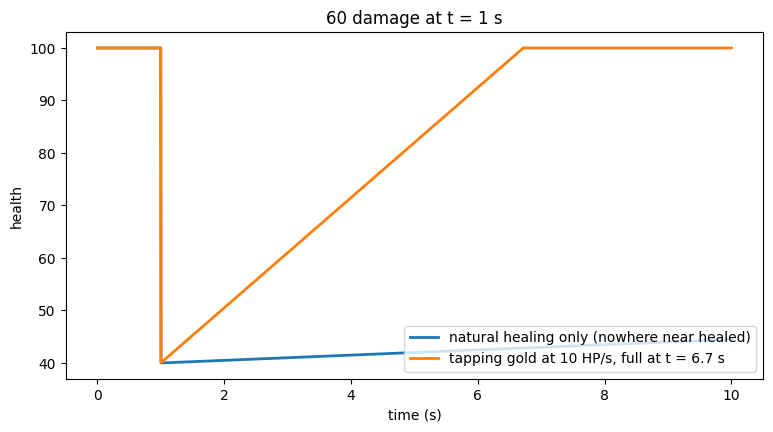

In [2]:
figure, ax = plt.subplots(figsize=(9, 4.5))

for label, tap_rate in [("natural healing only", 0), ("tapping gold at 10 HP/s", 10)]:
    world = World()
    wayne = world.add_body(Body("wayne", 70, (0, 0.3)))
    health = world.add_power(Health(wayne, max_health=100, natural_regen_per_second=0.5))
    goldmind = world.add_power(GoldFeruchemy(health, initial_reserve_health_points=100))

    world.run(1.0)
    health.damage(60)          # the gunshot
    if tap_rate:
        goldmind.tap(tap_rate)
    times, hp = run_sampling(world, 9.0, lambda: health.current)
    full_again = times[hp >= 99.9]
    recovery = f", full at t = {full_again[0]:.1f} s" if len(full_again) else " (nowhere near healed)"
    ax.plot(np.concatenate(([0, 1], times)), np.concatenate(([100, 100], hp)),
            linewidth=2, label=label + recovery)

ax.set_xlabel("time (s)")
ax.set_ylabel("health")
ax.set_title("60 damage at t = 1 s")
ax.legend(loc="lower right")
plt.show()

## Experiment B — sickly while storing

The deceptive nuance, on screen: storing is not free. Wayne sets the store
dial to 2 HP/s for 40 seconds. His natural healing (0.5 HP/s) fights back,
so he declines at a net 1.5 HP/s — genuinely, continuously less healthy the
entire time the gold is flowing in.

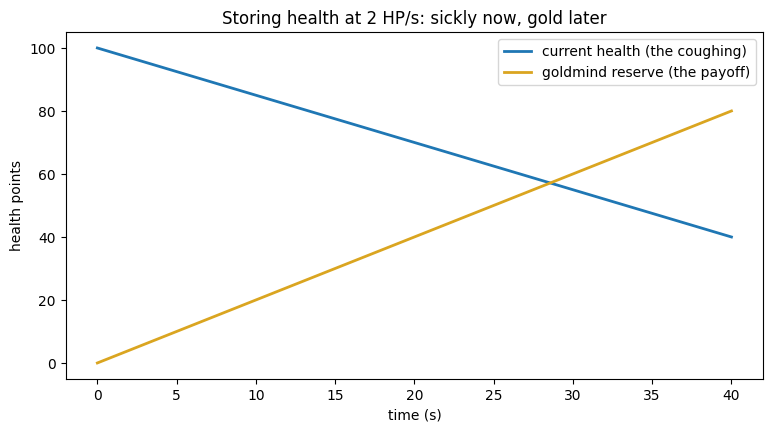

after 40 s storing: health 40/100, banked 80 HP


In [3]:
world = World()
wayne = world.add_body(Body("wayne", 70, (0, 0.3)))
health = world.add_power(Health(wayne, max_health=100, natural_regen_per_second=0.5))
goldmind = world.add_power(GoldFeruchemy(health))

goldmind.store(2.0)
times, samples = run_sampling(world, 40.0,
                              lambda: (health.current, goldmind.reserve_health_points))
hp, banked = samples[:, 0], samples[:, 1]

figure, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(times, hp, linewidth=2, label="current health (the coughing)")
ax.plot(times, banked, linewidth=2, color="goldenrod", label="goldmind reserve (the payoff)")
ax.set_xlabel("time (s)")
ax.set_ylabel("health points")
ax.set_title("Storing health at 2 HP/s: sickly now, gold later")
ax.legend()
plt.show()

print(f"after 40 s storing: health {hp[-1]:.0f}/100, banked {banked[-1]:.0f} HP")

## Experiment C — outhealing poison (or not)

A 5 HP/s poison, two wounded Waynes (40/100, natural healing off to isolate
the contest). One taps at 10 HP/s — gold beats venom. One taps at 3 HP/s —
venom beats gold. The survival boundary is exactly the poison rate; what the
plot adds is *time-to-death*, which is what a fight cares about.

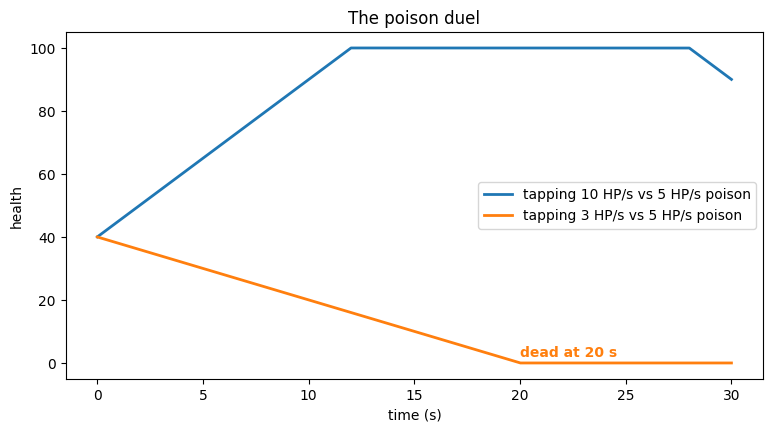

In [4]:
figure, ax = plt.subplots(figsize=(9, 4.5))

for label, tap_rate in [("tapping 10 HP/s vs 5 HP/s poison", 10),
                        ("tapping 3 HP/s vs 5 HP/s poison", 3)]:
    world = World()
    wayne = world.add_body(Body("wayne", 70, (0, 0.3)))
    health = world.add_power(Health(wayne, max_health=100, natural_regen_per_second=0))
    goldmind = world.add_power(GoldFeruchemy(health, initial_reserve_health_points=200))
    world.add_power(Poison(health, damage_per_second=5))
    health.damage(60)
    goldmind.tap(tap_rate)
    times, hp = run_sampling(world, 30.0, lambda: health.current)
    line, = ax.plot(times, hp, linewidth=2, label=label)
    if hp[-1] <= 0:
        time_of_death = times[np.argmax(hp <= 0)]
        ax.annotate(f"dead at {time_of_death:.0f} s", (time_of_death, 2),
                    color=line.get_color(), fontweight="bold")

ax.set_xlabel("time (s)")
ax.set_ylabel("health")
ax.set_title("The poison duel")
ax.legend(loc="center right")
plt.show()

## Findings

1. **Tapping gold is dramatic**: a wound that takes two minutes of natural
   healing closes in six seconds at 10 HP/s — rate control is the whole power.
2. **Storing is visibly miserable**: health sags the entire time the dial is
   set. The goldmind's value is exactly the misery prepaid into it. Zero-sum,
   on screen.
3. **Poison is a rate war**: tap rate above poison rate and you climb; below,
   you die on a schedule you can read off the chart. Reserve size decides how
   *long* you can hold the line — which will matter enormously for Miles.
4. **Next (05)**: bendalloy. Health and gold code in this notebook will not be
   touched at all — and Wayne will heal five times faster anyway. That's the
   point.